**Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC


import warnings
warnings.filterwarnings("ignore")


In [2]:
df= pd.read_csv("/kaggle/input/heart-disease-dataset-3k-rows-python-code-2025/heart_disease_dataset.csv")
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,smoking,diabetes,bmi,heart_disease
0,67,1,2,111,536,0,2,88,0,1.3,3,2,3,1,0,23.4,0
1,57,1,3,109,107,0,2,119,0,5.4,2,0,3,0,1,35.4,0
2,43,1,4,171,508,0,1,113,0,3.7,3,0,7,1,1,29.9,0
3,71,0,4,90,523,0,2,152,0,4.7,2,1,3,1,0,15.2,1
4,36,1,2,119,131,0,2,128,0,5.9,3,1,3,1,0,16.7,1


In [3]:
df.isna().sum()

age              0
sex              0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalach          0
exang            0
oldpeak          0
slope            0
ca               0
thal             0
smoking          0
diabetes         0
bmi              0
heart_disease    0
dtype: int64

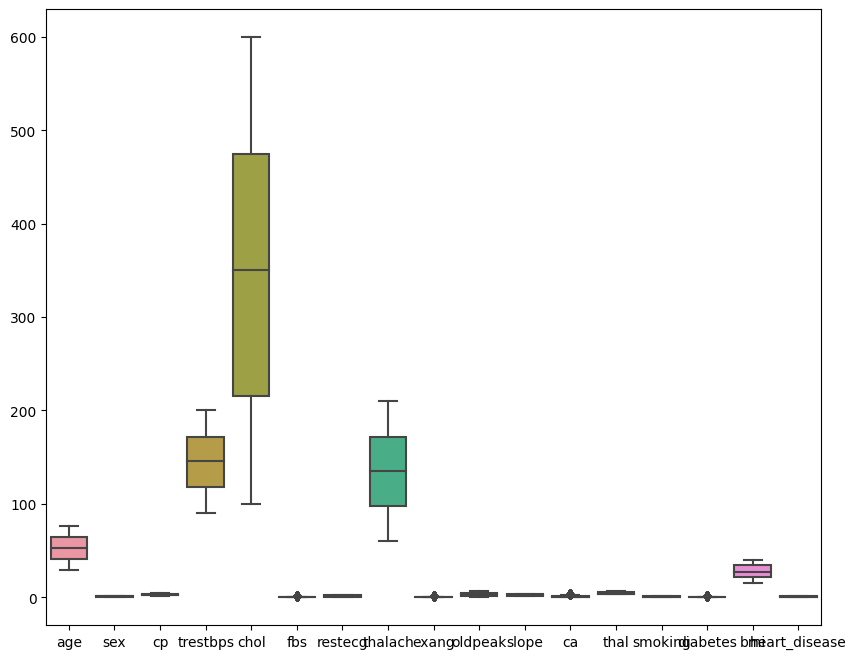

In [4]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df)
plt.show()

In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,smoking,diabetes,bmi,heart_disease
count,3069.00000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000
mean,52.50114,0.555556,2.489736,145.306289,347.219941,0.145650,1.004236,135.157380,0.176279,3.189052,2.023786,0.626588,4.544477,0.348974,0.193874,27.496839,0.403715
std,13.70752,0.496985,1.110417,31.602321,146.853319,0.352813,0.812016,43.353197,0.381119,1.802815,0.817679,0.891447,1.751064,0.476723,0.395396,7.281731,0.490721
min,29.00000,0.000000,1.000000,90.000000,100.000000,0.000000,0.000000,60.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,15.000000,0.000000
25%,41.00000,0.000000,2.000000,118.000000,215.000000,0.000000,0.000000,98.000000,0.000000,1.600000,1.000000,0.000000,3.000000,0.000000,0.000000,21.300000,0.000000
50%,53.00000,1.000000,2.000000,146.000000,350.000000,0.000000,1.000000,135.000000,0.000000,3.200000,2.000000,0.000000,3.000000,0.000000,0.000000,27.400000,0.000000
75%,64.00000,1.000000,3.000000,172.000000,475.000000,0.000000,2.000000,172.000000,0.000000,4.700000,3.000000,1.000000,6.000000,1.000000,0.000000,33.900000,1.000000
max,76.00000,1.000000,4.000000,200.000000,600.000000,1.000000,2.000000,210.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000,1.000000,40.000000,1.000000


In [6]:
ag=df.groupby('age')['chol'].agg(['min','max','mean'])


In [7]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'smoking', 'diabetes', 'bmi',
       'heart_disease'],
      dtype='object')

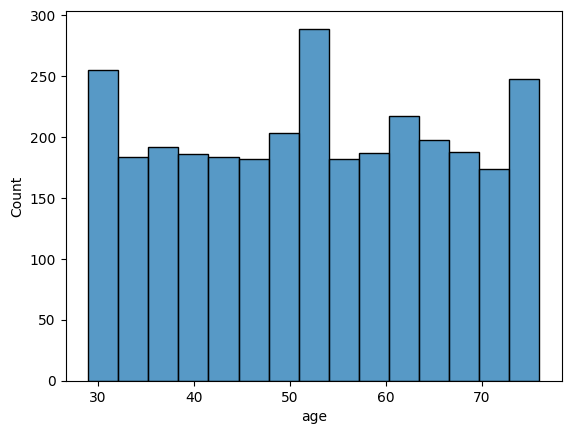

In [8]:
sns.histplot(data=df,x='age')
plt.show()

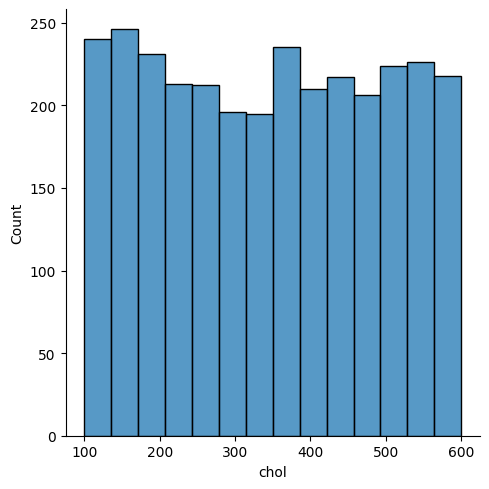

In [9]:
sns.displot(data=df,x='chol')
plt.show()

In [10]:
gender=df.groupby(np.where(df['sex']==0,'female','male'))['chol'].agg('mean')

gender


female    354.268328
male      341.581232
Name: chol, dtype: float64

In [11]:
df1 = df[['sex', 'chol','age']].copy()
df1['sex'] = df1['sex'].map({0: 'female', 1: 'male'})
print(df1)


         sex  chol  age
0       male   536   67
1       male   107   57
2       male   508   43
3     female   523   71
4       male   131   36
...      ...   ...  ...
3064  female   479   52
3065  female   372   75
3066    male   564   68
3067  female   113   66
3068    male   507   38

[3069 rows x 3 columns]


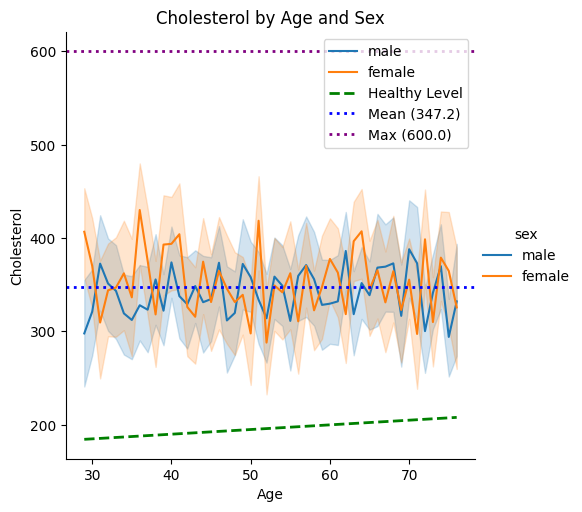

In [12]:
sns.relplot(data=df1, x='age', y='chol', kind='line', hue='sex')

# Create a healthy cholesterol line that gradually increases with age
ages = np.linspace(df1['age'].min(), df1['age'].max(), 100)
healthy_line = 180 + (ages - 20) * 0.5  # starts at 180 and increases 0.5 per year

plt.plot(ages, healthy_line, color='green', linestyle='--', linewidth=2, label='Healthy Level')

# Add mean and max cholesterol of the dataset
mean_chol = df1['chol'].mean()
max_chol = df1['chol'].max()
plt.axhline(mean_chol, color='blue', linestyle=':', linewidth=2, label=f'Mean ({mean_chol:.1f})')
plt.axhline(max_chol, color='purple', linestyle=':', linewidth=2, label=f'Max ({max_chol:.1f})')

plt.title("Cholesterol by Age and Sex")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.legend()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

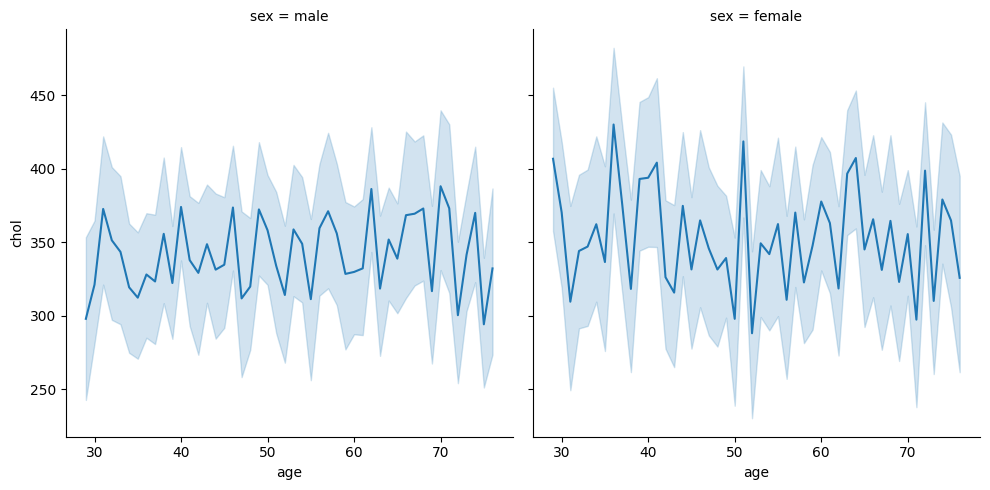

In [13]:
sns.relplot(data=df1,x='age',y='chol',col='sex',kind='line')
plt.show

In [14]:
df2= df[['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'smoking', 'diabetes', 'bmi',
       'heart_disease']].copy()
df2['sex']=df2['sex'].map({0:'female',1:'male'})
df2['diabetes']=df2['diabetes'].map({0:'No',1:'yes'})


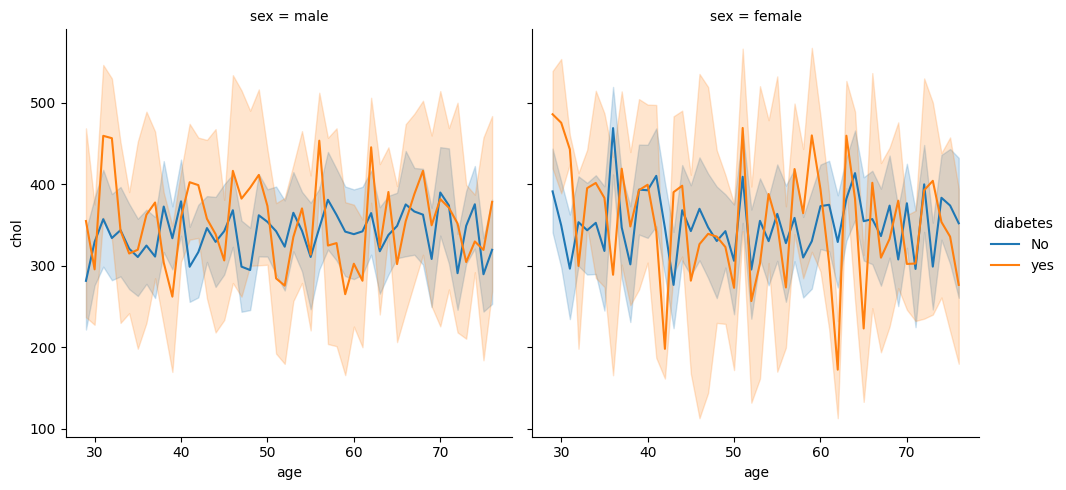

In [15]:
sns.relplot(data=df2,kind='line',x='age',y='chol',hue='diabetes',col='sex')
plt.show()

In [16]:
df2.groupby(['diabetes','sex','age'])['chol'].agg('mean')

diabetes  sex     age
No        female  29     391.040000
                  30     349.300000
                  31     296.300000
                  32     353.275862
                  33     343.384615
                            ...    
yes       male    72     351.666667
                  73     304.428571
                  74     329.666667
                  75     319.285714
                  76     378.200000
Name: chol, Length: 192, dtype: float64

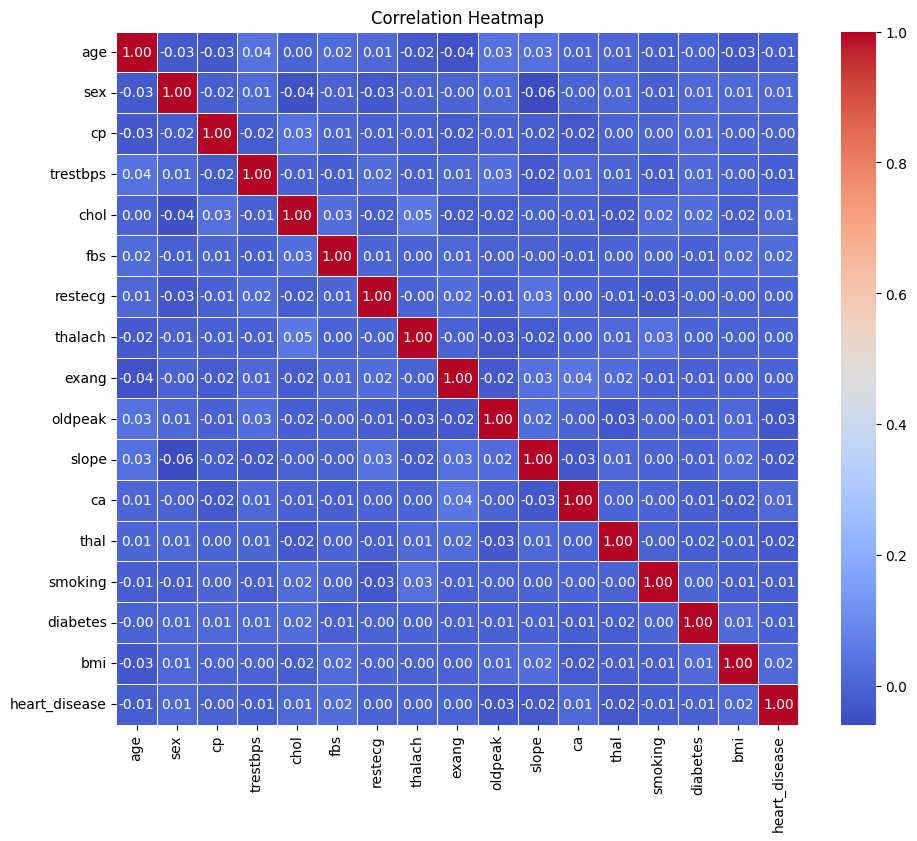

In [17]:
plt.figure(figsize=(11, 9))
sns.heatmap(data=df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [18]:
df2

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,smoking,diabetes,bmi,heart_disease
0,67,male,2,111,536,0,2,88,0,1.3,3,2,3,1,No,23.4,0
1,57,male,3,109,107,0,2,119,0,5.4,2,0,3,0,yes,35.4,0
2,43,male,4,171,508,0,1,113,0,3.7,3,0,7,1,yes,29.9,0
3,71,female,4,90,523,0,2,152,0,4.7,2,1,3,1,No,15.2,1
4,36,male,2,119,131,0,2,128,0,5.9,3,1,3,1,No,16.7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3064,52,female,1,169,479,0,0,124,0,3.7,2,3,3,0,No,27.8,0
3065,75,female,4,90,372,0,2,141,0,2.1,2,2,3,0,yes,37.0,1
3066,68,male,4,166,564,0,1,76,0,4.5,3,1,3,0,No,16.1,0
3067,66,female,3,143,113,1,1,207,0,3.6,1,0,6,0,No,27.7,0


In [19]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,smoking,diabetes,bmi,heart_disease
0,67,1,2,111,536,0,2,88,0,1.3,3,2,3,1,0,23.4,0
1,57,1,3,109,107,0,2,119,0,5.4,2,0,3,0,1,35.4,0
2,43,1,4,171,508,0,1,113,0,3.7,3,0,7,1,1,29.9,0
3,71,0,4,90,523,0,2,152,0,4.7,2,1,3,1,0,15.2,1
4,36,1,2,119,131,0,2,128,0,5.9,3,1,3,1,0,16.7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3064,52,0,1,169,479,0,0,124,0,3.7,2,3,3,0,0,27.8,0
3065,75,0,4,90,372,0,2,141,0,2.1,2,2,3,0,1,37.0,1
3066,68,1,4,166,564,0,1,76,0,4.5,3,1,3,0,0,16.1,0
3067,66,0,3,143,113,1,1,207,0,3.6,1,0,6,0,0,27.7,0


In [20]:
X= df.drop('diabetes', axis=1)
y= df['diabetes']
X_train,X_test,y_train,y_test  = train_test_split(X,y,test_size=0.2,stratify=y,random_state=1)
print(X_train)
print(y_train)

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
2348   41    0   4       141   497    0        2      105      0      2.6   
325    66    0   1       159   264    0        0      164      0      3.7   
701    66    0   4       105   408    0        2      195      0      2.9   
2791   41    1   2       194   178    0        1      206      0      0.0   
1809   33    0   4       132   317    0        2      116      1      4.1   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1319   29    1   4       172   397    0        2      144      0      2.6   
1491   50    0   3       134   188    0        1      165      0      2.6   
670    34    1   2       162   153    0        1       70      0      2.2   
1690   64    0   2        98   336    0        0      144      0      1.9   
719    48    1   4       188   210    0        2       85      0      4.1   

      slope  ca  thal  smoking   bmi  heart_disease  
2348      3   0     3

In [21]:


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
model = LogisticRegression(max_iter=1000,class_weight= 'balanced', random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [23]:
y_pred = model.predict(X_test_scaled)


In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.496742671009772

Confusion Matrix:
 [[251 244]
 [ 65  54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.51      0.62       495
           1       0.18      0.45      0.26       119

    accuracy                           0.50       614
   macro avg       0.49      0.48      0.44       614
weighted avg       0.68      0.50      0.55       614



In [25]:
print(model.predict(X_test.head(20)))


[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [26]:
df['diabetes'].value_counts()

diabetes
0    2474
1     595
Name: count, dtype: int64

In [27]:
model2= SVC(kernel='linear')
model2.fit(X_train_scaled,y_train)


SVC(kernel='linear')

In [28]:
y_pred2 = model2.predict(X_test)


In [29]:
print("Accuracy:", accuracy_score(y_test, y_pred2))


Accuracy: 0.8061889250814332
